In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [12]:
import pandas as pd

In [13]:
import os

# This lists every single file in your Kaggle input
for dirname, _, filenames in os.walk('/kaggle/input/datasets/tandooriwick/black-mamba'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/tandooriwick/black-mamba/KT4_merged.feather
/kaggle/input/datasets/tandooriwick/black-mamba/KT3_merged.feather
/kaggle/input/datasets/tandooriwick/black-mamba/2012-2013-data-with-predictions-4-final.csv


In [14]:
data = pd.read_csv('/kaggle/input/datasets/tandooriwick/black-mamba/2012-2013-data-with-predictions-4-final.csv')
data.head()

,problem_log_id,skill,problem_id,user_id,assignment_id,assistment_id,start_time,end_time,problem_type,original,...,overlap_time,template_id,answer_id,answer_text,first_action,problemlogid,Average_confidence(FRUSTRATED),Average_confidence(CONFUSED),Average_confidence(CONCENTRATING),Average_confidence(BORED)
0,137792159,NaN,557460,61394,565736,341511,2012-09-28 15:11:27,2012-09-28 15:11:36.856,choose_1,1,...,9852,341511,NaN,she,0,137792159,0.361323,0.0,0.336529,0.000000
1,138083797,Rounding,365981,61394,573819,204043,2012-10-09 11:01:52,2012-10-09 11:02:13.182,algebra,1,...,21175,204043,NaN,74.29,0,138083797,0.361323,0.0,0.766925,0.000000
2,142332619,Multiplication and Division Integers,426415,61394,734130,247525,2013-03-07 10:53:20,2013-03-07 10:53:28.661,algebra,1,...,8645,247525,NaN,00,0,142332619,0.361323,0.0,0.766925,0.442968
3,145939397,Proportion,86686,61394,821352,48081,2013-08-20 19:54:56,2013-08-20 19:55:21.753,algebra,1,...,25728,46362,NaN,3.8,0,145939397,0.775000,0.0,0.766925,0.912281
4,137111284,NaN,399669,76592,557216,227869,2012-09-10 17:20:10,2012-09-10 17:24:56.579,choose_1,1,...,286578,227869,NaN,C (wr - 1)(wr + 1),0,137111284,0.361323,0.0,0.766925,0.000000


In [15]:
print(data.isnull().sum())

problem_log_id                             0
skill                                3493190
problem_id                                 0
user_id                                    0
assignment_id                              0
assistment_id                              0
start_time                                 0
end_time                                   0
problem_type                               0
original                                   0
correct                                    0
bottom_hint                            60348
hint_count                                 0
actions                                    0
attempt_count                              0
ms_first_response                          0
tutor_mode                                 0
sequence_id                                0
student_class_id                           0
position                                   0
type                                       0
base_sequence_id                           0
skill_id  

In [16]:
print(data['skill'].value_counts())

skill
Equation Solving Two or Fewer Steps         192976
Addition and Subtraction Integers           151061
Addition and Subtraction Fractions          146992
Conversion of Fraction Decimals Percents     98629
Multiplication and Division Integers         84291
                                             ...  
Properties of Numbers                           14
Recognize Quadratic Pattern                      6
Combinatorics                                    4
Co-ordinate Points                               3
Rotational Symmetry                              1
Name: count, Length: 198, dtype: int64


In [17]:

data = data.dropna(subset=['skill'])

data['skill'] = data['skill'].fillna('Unknown')

In [18]:

data['start_time'] = pd.to_datetime(data['start_time'], format='mixed')
data['end_time'] = pd.to_datetime(data['end_time'], format='mixed')


data['duration'] = (data['end_time'] - data['start_time']).dt.total_seconds()

print("Timestamps converted successfully!")
print(data[['start_time', 'end_time', 'duration']].head())

Timestamps converted successfully!
           start_time                end_time  duration
1 2012-10-09 11:01:52 2012-10-09 11:02:13.182    21.182
2 2013-03-07 10:53:20 2013-03-07 10:53:28.661     8.661
3 2013-08-20 19:54:56 2013-08-20 19:55:21.753    25.753
5 2012-12-12 21:00:55 2012-12-12 21:01:07.536    12.536
7 2012-10-16 10:30:54 2012-10-16 10:31:55.445    61.445


In [19]:

cols_to_keep = ['user_id', 'skill', 'problem_id', 'duration', 'problem_type']
data_cleaned = data[cols_to_keep]

In [20]:
data_cleaned = data_cleaned.drop_duplicates()
print(f"Cleaned data shape: {data_cleaned.shape}")

Cleaned data shape: (2630080, 5)


In [21]:
print(data['correct'].value_counts(normalize=True))

correct
1.00    6.962708e-01
0.00    3.036493e-01
0.75    4.562599e-05
0.50    1.596910e-05
0.25    9.505414e-06
0.60    7.604331e-06
0.65    7.604331e-07
0.95    3.802166e-07
Name: proportion, dtype: float64


In [22]:
skill_difficulty = data.groupby('skill')['correct'].mean().sort_values()
print("Top 5 Hardest Skills:")
print(skill_difficulty.head(5))

Top 5 Hardest Skills:
skill
Combinatorics                     0.000000
Recognize Quadratic Pattern       0.000000
Line Symmetry                     0.107595
Division Mixed Fractions          0.170697
Multiplication Mixed Fractions    0.190722
Name: correct, dtype: float64


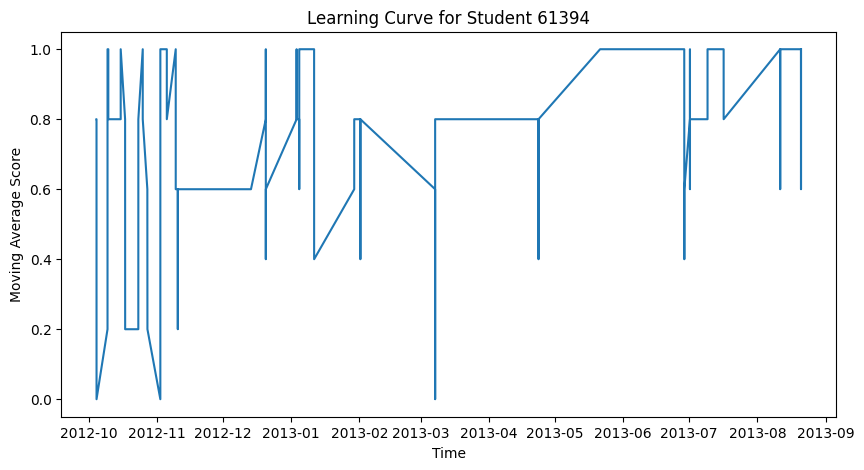

In [23]:
import matplotlib.pyplot as plt

student_id = data['user_id'].iloc[0] 
student_data = data[data['user_id'] == student_id].sort_values('start_time')

plt.figure(figsize=(10, 5))
plt.plot(student_data['start_time'], student_data['correct'].rolling(window=5).mean())
plt.title(f"Learning Curve for Student {student_id}")
plt.xlabel("Time")
plt.ylabel("Moving Average Score")
plt.show()

In [24]:
print(data_cleaned.columns.tolist())

['user_id', 'skill', 'problem_id', 'duration', 'problem_type']


In [25]:
print(data.columns)

print(data.nunique())

Index(['problem_log_id', 'skill', 'problem_id', 'user_id', 'assignment_id',
       'assistment_id', 'start_time', 'end_time', 'problem_type', 'original',
       'correct', 'bottom_hint', 'hint_count', 'actions', 'attempt_count',
       'ms_first_response', 'tutor_mode', 'sequence_id', 'student_class_id',
       'position', 'type', 'base_sequence_id', 'skill_id', 'teacher_id',
       'school_id', 'overlap_time', 'template_id', 'answer_id', 'answer_text',
       'first_action', 'problemlogid', 'Average_confidence(FRUSTRATED)',
       'Average_confidence(CONFUSED)', 'Average_confidence(CONCENTRATING)',
       'Average_confidence(BORED)', 'duration'],
      dtype='object')
problem_log_id                       2630080
skill                                    198
problem_id                             50988
user_id                                28834
assignment_id                         169748
assistment_id                          45400
start_time                           2311809
end_tim

In [26]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()


data_cleaned['skill_id'] = le.fit_transform(data_cleaned['skill'])
data_cleaned['type_id'] = le.fit_transform(data_cleaned['problem_type'])

print("Text data has been converted to numbers!")

Text data has been converted to numbers!


In [27]:

cols_to_keep = [
    'user_id', 'skill', 'skill_id', 'problem_id', 'duration', 
    'problem_type', 'correct', 'hint_count', 'attempt_count', 'ms_first_response'
]

data_cleaned = data[cols_to_keep].copy()

print("Columns successfully added:", data_cleaned.columns.tolist())

Columns successfully added: ['user_id', 'skill', 'skill_id', 'problem_id', 'duration', 'problem_type', 'correct', 'hint_count', 'attempt_count', 'ms_first_response']


In [28]:
# 1.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 2.
features = ['skill_id', 'user_id', 'duration', 'hint_count', 'attempt_count', 'ms_first_response']
X = data_cleaned[features].fillna(0)
y = data_cleaned['correct']

# 3. 
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.1, random_state=42)

# 4. 
model = RandomForestRegressor(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully on a 10% sample!")

Model trained successfully on a 10% sample!


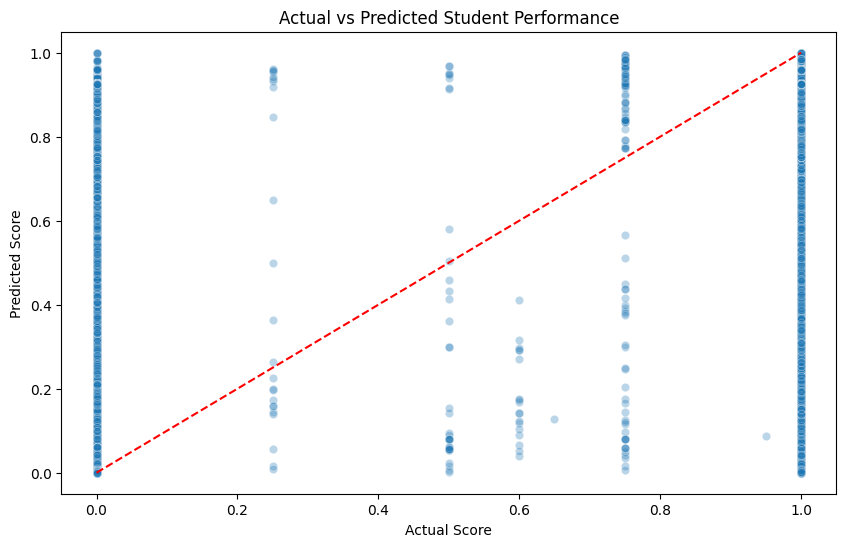

In [30]:
# 1. 
y_pred = model.predict(X_test)

# 2. 
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([0, 1], [0, 1], color='red', linestyle='--') 
plt.title('Actual vs Predicted Student Performance')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.show()

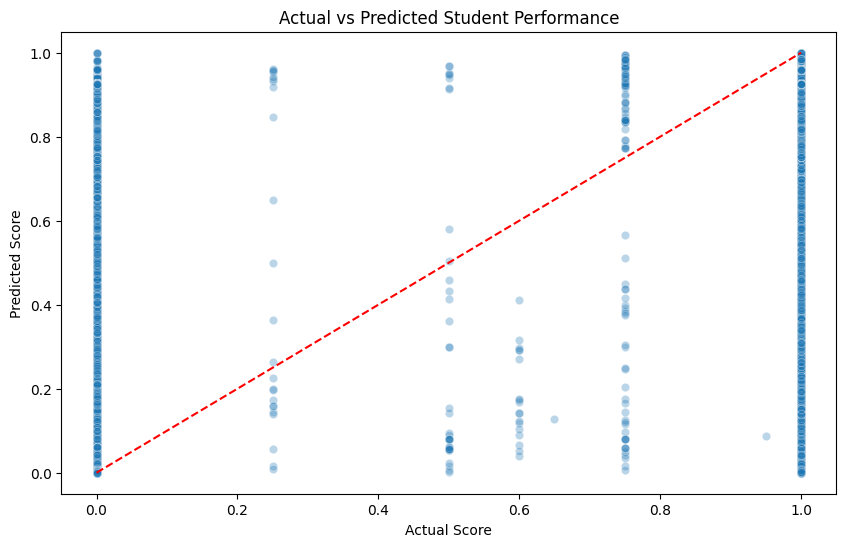

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.3)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('Actual vs Predicted Student Performance')
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.show()

In [32]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")
print(f"R2 Score (Accuracy): {r2:.2f}")

Mean Absolute Error: 0.12
R2 Score (Accuracy): 0.73


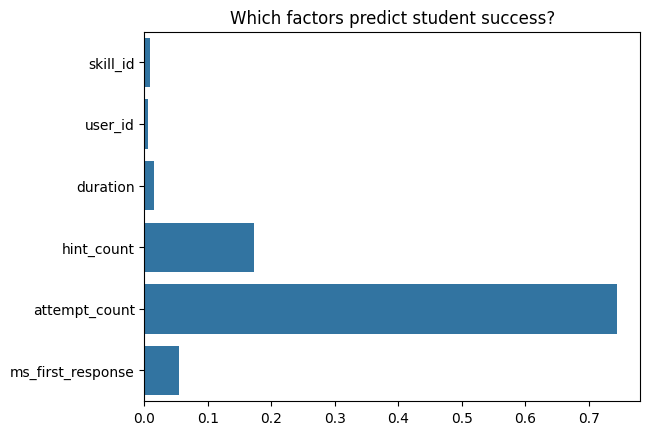

In [33]:
importances = model.feature_importances_
sns.barplot(x=importances, y=['skill_id', 'user_id', 'duration', 'hint_count', 'attempt_count', 'ms_first_response'])
plt.title('Which factors predict student success?')
plt.show()

In [34]:
def get_recommendation(student_id, skill_name):
    
    predicted_score = model.predict(X_test.iloc[0:1])[0]
    
    print(f"Student: {student_id} | Skill: {skill_name}")
    print(f"Predicted Success Probability: {predicted_score:.2f}")
    
    if predicted_score < 0.4:
        return "Recommendation: Show Video Tutorial (Student is struggling)"
    elif predicted_score < 0.7:
        return "Recommendation: Provide Similar Practice Problem"
    else:
        return "Recommendation: Level Up! (Student has mastered this)"

print(get_recommendation(61394, "Rounding"))

Student: 61394 | Skill: Rounding
Predicted Success Probability: 0.00
Recommendation: Show Video Tutorial (Student is struggling)


In [35]:
import joblib

joblib.dump(model, 'skillify_model.pkl')
print("Model saved as skillify_model.pkl")

Model saved as skillify_model.pkl
